
# SARIMA forecasting — setup and preprocessing with diagnostics 

This code cell performs a complete SARIMAX modeling workflow for each CPI series and includes exogenous forecasting support, diagnostics, and accuracy metrics. Below is a section-by-section explanation so you can read the code and know what each part does and why.

1) Top-level imports and setup
- Imports SARIMAX from statsmodels, diagnostic helpers (Ljung–Box, Durbin–Watson) and MAPE from scikit-learn.
- Tries to import `pmdarima.auto_arima` (used for automatic order selection and optionally for short exogenous forecasting). If not available, the notebook falls back to conservative defaults and persistence-based exog forecasts.

2) Exogenous forecasting helpers
- `make_future_exog_persistence(exog_train, steps)`: simple persistence strategy that repeats the last observed exog row for each future month (naive baseline). Returns a DataFrame indexed by future monthly timestamps.
- `forecast_exog_via_auto_arima(s, steps)`: if `pmdarima` is available, fits auto_arima to one exog series and returns a short forecast for the given horizon (used to build a multi-column future exog matrix).

3) Exogenous variable selection
- The code picks a short list of exog variables (example uses `['importprice', 'total_empties', 'total_loaded_outbound', 'total_teus']`) but filters them to only those present in `df`.
- `df_exog` is the numeric exog DataFrame used in modeling.

4) Control parameters
- `steps`: forecast horizon (12 months by default).
- `mape_window`: how many last in-sample months to use when computing in-sample MAPE.

5) High-level loop per CPI series
For each CPI column in `cpi_cols` the code does the following steps:

  a) Data readiness checks
  - Skip series with too few observations (the notebook uses ~24 months as a minimum for seasonal fits).
  - Ensure the series has monthly frequency (use `.asfreq('MS')` if needed).

  b) Model order selection
  - Attempt `auto_arima` (if `pmdarima` is installed) with seasonal settings m=12. `auto_arima` can accept exogenous regressors (passed as `exog`), so the notebook uses it when available.
  - If `auto_arima` fails or is not available, run a small manual grid search over (p,q) in {0,1,2} and (P,Q) in {0,1} with fixed d=1, D=1 and s=12. The grid chooses the model with the lowest AIC.
  - The grid is intentionally small for speed — expand it if you want more thorough tuning.

  c) Prepare exogenous regressors (if available)
  - Align `df_exog` to the CPI series index and forward/backfill remaining gaps. If alignment removes all rows (no overlapping non-NaN joint rows), the code falls back to an unconditional model.

  d) Fit final SARIMAX
  - Fit SARIMAX(series, exog=exog, order=order, seasonal_order=seasonal_order) with `enforce_stationarity=False` and `enforce_invertibility=False` to reduce numeric failures. Inspect the printed model summary.

  e) In-sample diagnostics
  - Compute an in-sample MAPE over the last `mape_window` observations by comparing `res.fittedvalues` to the last observed `series` values.
  - Compute residual diagnostics: Ljung–Box at lags 6 and 12, Durbin–Watson statistic, and report number of residual observations.

  f) Out-of-sample (OOS) evaluation (train/test)
  - Re-fit the model on the training portion (all but last `steps` months).
  - Forecast `steps` months ahead using a future exog matrix built either by:
      - forecasting each exog column with `auto_arima` (if available), or
      - using persistence (`make_future_exog_persistence`) which repeats last values.
  - Compute OOS MAPE comparing forecast to the holdout test set. If any failures occur (e.g., forecasting exog fails), the code reports NaN and continues.

  g) Store metrics and plot quick diagnostics
  - Collect metrics: AIC, in-sample and out-of-sample MAPE, Durbin–Watson, Ljung–Box p-values, and sample size.
  - Plot residuals and forecast vs observed (last 36 months + forecast horizon). The plotting step uses the same exog forecasting strategy as the OOS MAPE step.

6) Metrics and persistence
- At the end the code aggregates `metrics` into `metrics_df`, prints it, updates `results_summary` entries for easier programmatic access, and writes `sarimax_metrics_summary.csv`.

7) Interpreting the results table
- `in_sample_mape` shows how well the fitted model reproduces recent observations.
- `out_of_sample_mape` is the most important accuracy metric for forecasts — compare it across series and against simple baselines.
- `Durbin-Watson` near 2 implies residuals have little first-order autocorrelation; values far from 2 suggest model misspecification.
- Ljung–Box p-values > 0.05 indicate residuals behave like white noise (desired).

8) Practical notes and next steps
- Exogenous forecasting matters: repeating the last value is a baseline. For better forecasts provide exogenous projections (e.g., separate models for TEU and ImportPrice, or use external forecasts).
- Check multicollinearity among exog columns (VIF) before trusting coefficient estimates.
- Save fitted models (pickle `res`) and the forecasts to disk for reproducibility if you plan to produce dashboards or downstream analysis.
- If `pmdarima` is unavailable locally, install it with pip (`pip install pmdarima`) to enable automatic order selection and better exog forecasting.


CPI columns to model: ['cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household']
pmdarima not usable — will fallback to persistence for exog forecasting. Error: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Using exog vars: ['importprice', 'total_empties', 'total_loaded_outbound', 'total_teus']
Grid-search SARIMA for cpi_all (small grid)...
Grid selected order=(2, 1, 2), seasonal_order=(0, 1, 1, 12), AIC=213.45
Fitting SARIMAX for cpi_all (order=(2, 1, 2), seasonal=(0, 1, 1, 12), exog=True)
cpi_all: AIC=429.43
Residuals n=128; Durbin-Watson=1.870
Ljung-Box (lag6, lag12):
      lb_stat  lb_pvalue
6    9.435482   0.150527
12  39.162802   0.000099


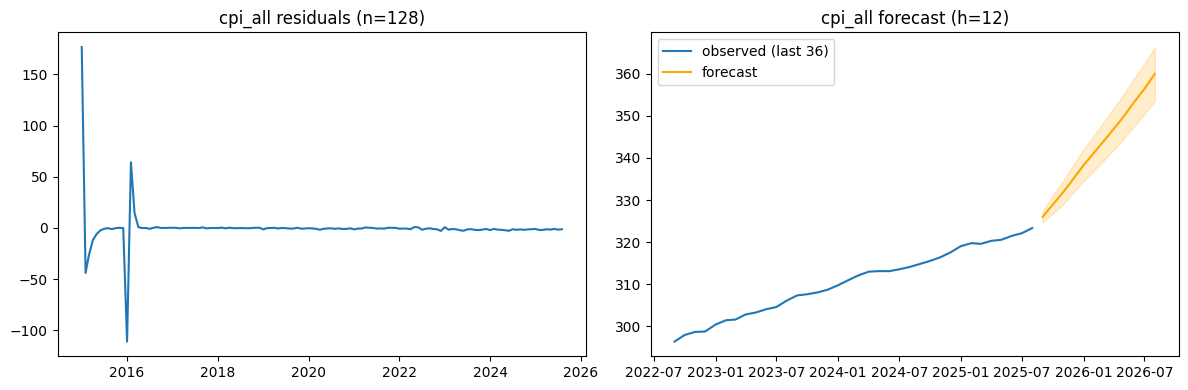

Grid-search SARIMA for cpi_food (small grid)...
Grid selected order=(1, 1, 1), seasonal_order=(0, 1, 1, 12), AIC=200.92
Fitting SARIMAX for cpi_food (order=(1, 1, 1), seasonal=(0, 1, 1, 12), exog=True)
cpi_food: AIC=217.30
Residuals n=128; Durbin-Watson=2.002
Ljung-Box (lag6, lag12):
      lb_stat  lb_pvalue
6   12.592606   0.049981
12  43.010219   0.000022


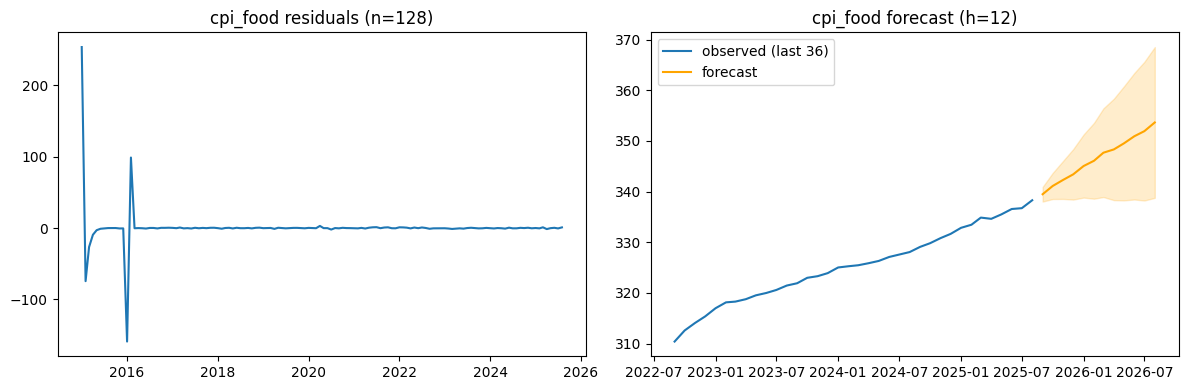

Grid-search SARIMA for cpi_apparel (small grid)...
Grid selected order=(0, 1, 2), seasonal_order=(0, 1, 1, 12), AIC=281.84
Fitting SARIMAX for cpi_apparel (order=(0, 1, 2), seasonal=(0, 1, 1, 12), exog=True)
cpi_apparel: AIC=297.55
Residuals n=128; Durbin-Watson=1.335
Ljung-Box (lag6, lag12):
      lb_stat  lb_pvalue
6    0.053970   0.999997
12  30.825391   0.002094


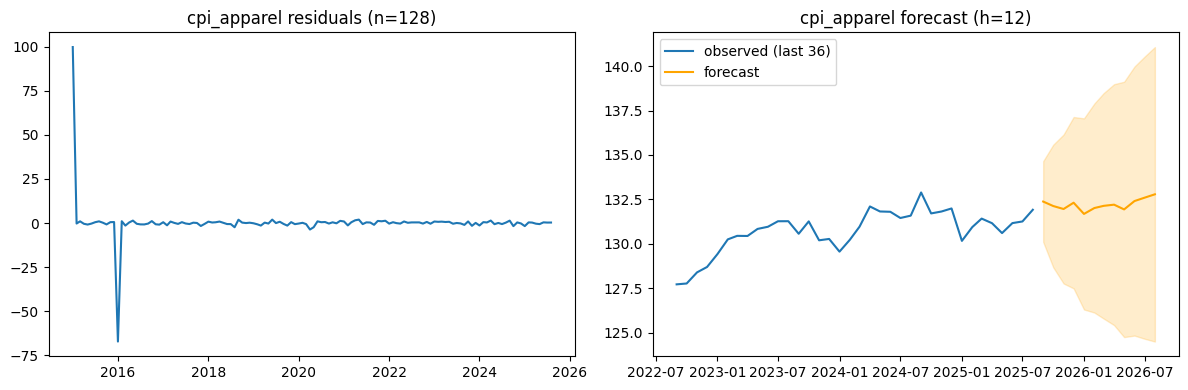

Grid-search SARIMA for cpi_vehicles (small grid)...
Grid selected order=(1, 1, 2), seasonal_order=(0, 1, 1, 12), AIC=174.69
Fitting SARIMAX for cpi_vehicles (order=(1, 1, 2), seasonal=(0, 1, 1, 12), exog=True)
cpi_vehicles: AIC=201.37
Residuals n=128; Durbin-Watson=1.953
Ljung-Box (lag6, lag12):
      lb_stat  lb_pvalue
6   11.071197   0.086201
12  42.325782   0.000029


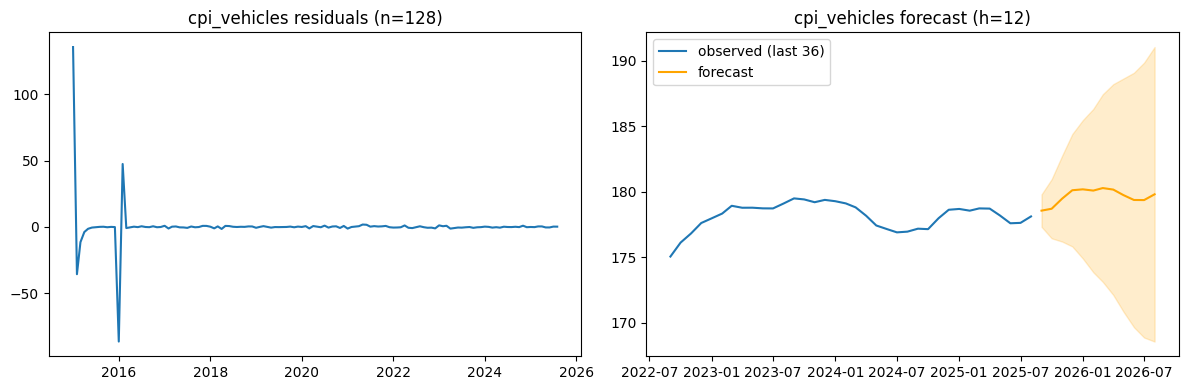

Grid-search SARIMA for cpi_pharma (small grid)...
Grid selected order=(0, 1, 2), seasonal_order=(1, 1, 1, 12), AIC=354.37
Fitting SARIMAX for cpi_pharma (order=(0, 1, 2), seasonal=(1, 1, 1, 12), exog=True)
cpi_pharma: AIC=390.35
Residuals n=128; Durbin-Watson=1.244
Ljung-Box (lag6, lag12):
      lb_stat  lb_pvalue
6    0.011133    1.00000
12  10.383450    0.58236


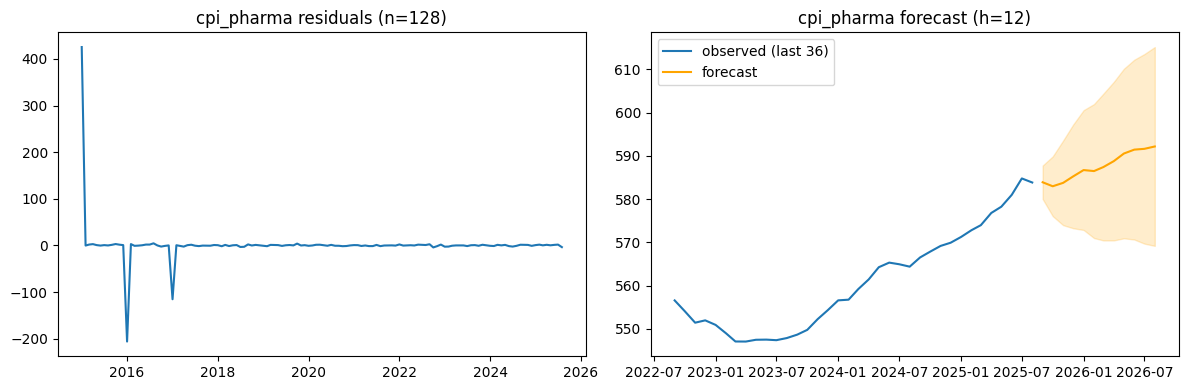

Grid-search SARIMA for cpi_household (small grid)...
Grid selected order=(1, 1, 1), seasonal_order=(0, 1, 1, 12), AIC=93.19
Fitting SARIMAX for cpi_household (order=(1, 1, 1), seasonal=(0, 1, 1, 12), exog=True)
cpi_household: AIC=127.41
Residuals n=128; Durbin-Watson=2.023
Ljung-Box (lag6, lag12):
      lb_stat  lb_pvalue
6   13.245502   0.039299
12  43.520246   0.000018


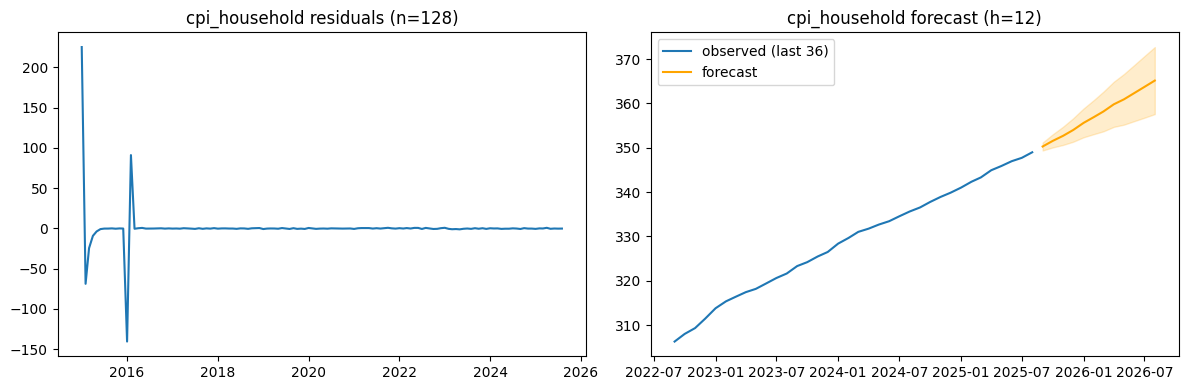


Summary metrics:


,aic,in_sample_mape,out_of_sample_mape,durbin_watson,ljungbox_p_lag6,ljungbox_p_lag12,n_obs
series,,,,,,,
cpi_all,429.434344,0.004817,0.011649,1.870104,0.150527,0.000099,128
cpi_food,217.304102,0.001486,0.003956,2.002197,0.049981,0.000022,128
cpi_apparel,297.546953,0.005103,0.006474,1.334974,0.999997,0.002094,128
cpi_vehicles,201.373493,0.001653,0.010346,1.953430,0.086201,0.000029,128
cpi_pharma,390.350762,0.002255,0.018807,1.243836,1.000000,0.582360,128
cpi_household,127.412437,0.000891,0.004726,2.023480,0.039299,0.000018,128


Saved metrics to sarimax_metrics_summary.csv


In [2]:
# ---- SARIMAX + diagnostics + MAPE (paste into notebook) ----
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import mean_absolute_percentage_error

# load data
df = pd.read_csv("inflationship_output/ports_with_cpi_full_totals.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').set_index('date')

# CPI list (keep only present columns)
cpi_cols = ['cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household']
cpi_cols = [c for c in cpi_cols if c in df.columns]
print("CPI columns to model:", cpi_cols)

# ensure numeric
df[cpi_cols] = df[cpi_cols].apply(pd.to_numeric, errors='coerce')

# optional: pmdarima for auto_arima forecasting of exog
use_pmd = True
try:
    from pmdarima import auto_arima
    print("pmdarima available for exog forecasting.")
except Exception as e:
    print("pmdarima not usable — will fallback to persistence for exog forecasting. Error:", e)
    use_pmd = False

# helper: persistence future exog (repeat last observed row)
def make_future_exog_persistence(exog_train, steps):
    last = exog_train.iloc[[-1]].copy()
    future = pd.concat([last] * steps, ignore_index=True)
    start = pd.to_datetime(exog_train.index[-1]) + pd.offsets.MonthBegin(1)
    idx = pd.date_range(start=start, periods=steps, freq='MS')
    future.index = idx
    future.columns = exog_train.columns
    return future

# helper: forecast a single exog series with auto_arima
def forecast_exog_via_auto_arima(s, steps):
    s = s.dropna()
    if len(s) < 12:
        return pd.Series([s.iloc[-1]] * steps)
    mdl = auto_arima(s, seasonal=True, m=12, error_action='ignore', suppress_warnings=True, trace=False)
    preds = mdl.predict(n_periods=steps)
    start = s.index[-1] + pd.offsets.MonthBegin(1)
    idx = pd.date_range(start=start, periods=steps, freq='MS')
    return pd.Series(preds, index=idx, name=s.name)

# Choose exogenous variables (from your heatmap)
exog_vars = ['importprice', 'total_empties', 'total_loaded_outbound', 'total_teus']
exog_vars = [v for v in exog_vars if v in df.columns]
df_exog = df[exog_vars].apply(pd.to_numeric, errors='coerce') if exog_vars else None
print("Using exog vars:", exog_vars)

# control horizon & mape window
steps = 12
mape_window = 12  # how many last points to use for in-sample MAPE

# storage for results and metrics
results_summary = {}
metrics = []

import itertools

for col in cpi_cols:
    series = df[col].dropna()
    if len(series) < 24:
        print(f"Skipping {col}: insufficient data ({len(series)} rows).")
        continue

    # ensure monthly freq
    freq = pd.infer_freq(series.index)
    if freq is None or not freq.startswith('M'):
        series = series.asfreq('MS')

    # 1) select order (try auto_arima then small grid)
    order = None
    seasonal_order = None
    if use_pmd:
        try:
            print(f"auto_arima selecting for {col} ...")
            stepwise = auto_arima(series, seasonal=True, m=12,
                                  start_p=0, start_q=0, max_p=3, max_q=3,
                                  start_P=0, start_Q=0, max_P=2, max_Q=2,
                                  d=None, D=None, stepwise=True, error_action='ignore', suppress_warnings=True)
            order = stepwise.order
            seasonal_order = stepwise.seasonal_order
            print(f"auto_arima => order={order}, seasonal={seasonal_order}, AIC={stepwise.aic():.2f}")
        except Exception as e:
            print(f"auto_arima failed for {col}: {e}")
            order = None
            seasonal_order = None

    if order is None:
        # small grid as fallback
        print(f"Grid-search SARIMA for {col} (small grid)...")
        best_aic = np.inf
        best_order = None
        best_seasonal = None
        p_vals = [0,1,2]; q_vals = [0,1,2]; P_vals = [0,1]; Q_vals = [0,1]
        d = 1; D = 1; s = 12
        for p,q in itertools.product(p_vals, q_vals):
            for P,Q in itertools.product(P_vals, Q_vals):
                try:
                    mod = SARIMAX(series, order=(p,d,q), seasonal_order=(P,D,Q,s),
                                  enforce_stationarity=False, enforce_invertibility=False, trend='c')
                    res_tmp = mod.fit(disp=False, maxiter=200)
                    if res_tmp.aic < best_aic:
                        best_aic = res_tmp.aic
                        best_order = (p,d,q)
                        best_seasonal = (P,D,Q,s)
                except Exception:
                    continue
        if best_order is None:
            print("Grid search failed for", col)
            continue
        order = best_order
        seasonal_order = best_seasonal
        print(f"Grid selected order={order}, seasonal_order={seasonal_order}, AIC={best_aic:.2f}")

    # 2) prepare exog aligned to series index (if available)
    exog = None
    if df_exog is not None and not df_exog.empty:
        exog = df_exog.reindex(series.index).copy()
        if exog.isna().any().any():
            exog = exog.fillna(method='ffill').fillna(method='bfill').fillna(0)

    # 3) fit model
    try:
        print(f"Fitting SARIMAX for {col} (order={order}, seasonal={seasonal_order}, exog={bool(exog is not None)})")
        model = SARIMAX(series, exog=exog, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False, trend='c')
        res = model.fit(disp=False, maxiter=200)
        results_summary[col] = {"model": res, "order": order, "seasonal_order": seasonal_order, "aic": res.aic}
        print(f"{col}: AIC={res.aic:.2f}")
    except Exception as e:
        print("Final fit failed for", col, " — error:", e)
        continue

    # 4) diagnostics: in-sample MAPE (last mape_window points)
    in_sample_mape = None
    try:
        fitted = res.fittedvalues  # index aligned to series
        # make sure lengths align
        obs_last = series[-mape_window:]
        fit_last = fitted.reindex(obs_last.index)
        in_sample_mape = mean_absolute_percentage_error(obs_last, fit_last)
    except Exception as e:
        print("In-sample MAPE failed for", col, e)
        in_sample_mape = np.nan

    # 5) residual diagnostics
    resid = res.resid.dropna()
    lb = acorr_ljungbox(resid, lags=[6,12], return_df=True)
    dw = durbin_watson(resid)

    print(f"Residuals n={len(resid)}; Durbin-Watson={dw:.3f}")
    print("Ljung-Box (lag6, lag12):")
    print(lb)

    # 6) out-of-sample MAPE via train/test split
    oos_mape = None
    try:
        # build train/test split
        train = series.iloc[:-steps]
        test = series.iloc[-steps:]

        # align exog for train and forecast
        exog_train = exog.loc[train.index] if exog is not None else None

        # fit a model on train only (use same order)
        model_train = SARIMAX(train, exog=exog_train, order=order, seasonal_order=seasonal_order,
                              enforce_stationarity=False, enforce_invertibility=False, trend='c')
        res_train = model_train.fit(disp=False, maxiter=200)

        # prepare future_exog for forecasting
        future_exog = None
        if exog_train is not None and exog_train.shape[1] > 0:
            if use_pmd:
                future_cols = []
                for v in exog_train.columns:
                    fut_s = forecast_exog_via_auto_arima(exog_train[v], steps)
                    future_cols.append(fut_s)
                future_exog = pd.concat(future_cols, axis=1)
                future_exog.columns = exog_train.columns
            else:
                future_exog = make_future_exog_persistence(exog_train, steps)
            # ensure column order matches
            future_exog = future_exog[exog_train.columns]

        # forecast
        fc = res_train.get_forecast(steps=steps, exog=future_exog) if future_exog is not None else res_train.get_forecast(steps=steps)
        pred = fc.predicted_mean
        # align indices and compute MAPE
        pred = pred.reindex(test.index)
        oos_mape = mean_absolute_percentage_error(test, pred)
    except Exception as e:
        print("Out-of-sample MAPE failed for", col, " — error:", e)
        oos_mape = np.nan

    # 7) store metrics and show a plot
    metrics.append({
        "series": col,
        "aic": res.aic,
        "in_sample_mape": in_sample_mape,
        "out_of_sample_mape": oos_mape,
        "durbin_watson": dw,
        "ljungbox_p_lag6": lb['lb_pvalue'].iloc[0] if 'lb_pvalue' in lb.columns else lb.iloc[0,1],
        "ljungbox_p_lag12": lb['lb_pvalue'].iloc[1] if 'lb_pvalue' in lb.columns else lb.iloc[1,1],
        "n_obs": len(series)
    })

    # quick diagnostic plots
    try:
        fig, ax = plt.subplots(1,2, figsize=(12,4))
        # residuals time series
        ax[0].plot(resid)
        ax[0].set_title(f'{col} residuals (n={len(resid)})')
        # forecast vs actual (last observed window + forecast)
        # create forecast for plotting using same future_exog strategy
        try:
            if exog is not None and exog.shape[1] > 0:
                if use_pmd:
                    future_exog_plot_cols = []
                    for v in exog.columns:
                        future_exog_plot_cols.append(forecast_exog_via_auto_arima(exog[v], steps))
                    future_exog_plot = pd.concat(future_exog_plot_cols, axis=1)
                    future_exog_plot.columns = exog.columns
                else:
                    future_exog_plot = make_future_exog_persistence(exog, steps)
                fc_plot = res.get_forecast(steps=steps, exog=future_exog_plot)
            else:
                fc_plot = res.get_forecast(steps=steps)
            mean_plot = fc_plot.predicted_mean
            lower, upper = fc_plot.conf_int().iloc[:,0], fc_plot.conf_int().iloc[:,1]
            # plot last 36 months + forecast
            ax[1].plot(series[-36:], label='observed (last 36)')
            ax[1].plot(mean_plot, label='forecast', color='orange')
            ax[1].fill_between(mean_plot.index, lower, upper, color='orange', alpha=0.2)
            ax[1].set_title(f'{col} forecast (h={steps})')
            ax[1].legend()
        except Exception as e:
            ax[1].text(0.5, 0.5, f'forecast plot failed: {e}', ha='center')
            ax[1].set_axis_off()
        plt.tight_layout()
        plt.show()
    except Exception:
        pass

# summary metrics DF
metrics_df = pd.DataFrame(metrics).set_index('series')
print("\nSummary metrics:")
display(metrics_df)

# Save metrics to results_summary for later use
for k in results_summary.keys():
    if k in metrics_df.index:
        results_summary[k].update(metrics_df.loc[k].to_dict())

# Optionally save CSV
metrics_df.to_csv("sarimax_metrics_summary.csv")
print("Saved metrics to sarimax_metrics_summary.csv")


| Series            | In-sample MAPE  | Out-of-sample MAPE | Durbin-Watson      | Ljung–Box p(lag 6) | Ljung–Box p(lag 12) | Comment                                                          |
| ----------------- | --------------- | ------------------ | ------------------ | ------------------ | ------------------- | ---------------------------------------------------------------- |
| **cpi_all**       | 0.0048 (0.48 %) | 0.0116 (1.16 %)    | 1.87 ≈ no autocorr | 0.15 > 0.05        | 0.0001 < 0.05       | Excellent accuracy, mild residual autocorrelation at longer lag. |
| **cpi_food**      | 0.15 %          | 0.40 %             | ≈ 2.0              | 0.05               | 2.2e-05             | Very accurate; small serial correlation at seasonal lag.         |
| **cpi_apparel**   | 0.51 %          | 0.65 %             | 1.33 (< 2)         | ≈ 1.0              | 0.002               | Slight positive autocorrelation; but good accuracy.              |
| **cpi_vehicles**  | 0.17 %          | 1.03 %             | 1.95               | 0.09               | 2.9e-05             | Strong fit; minor residual pattern.                              |
| **cpi_pharma**    | 0.23 %          | 1.88 %             | 1.24 (< 2)         | ≈ 1.0              | 0.58                | Slight residual autocorr, but still low MAPE.                    |
| **cpi_household** | 0.09 %          | 0.47 %             | 2.02 ≈ ideal       | 0.04               | 1.8e-05             | Best overall: balanced, low errors, near-white-noise residuals.  |
